# 👥 HR Employee Attrition Analysis
### IBM HR Analytics Dataset — EDA & Business Insights
**Tools:** Python · Pandas · Matplotlib · Seaborn


---
## 📌 Step 1 — Libraries & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', None)

print('✅ Libraries loaded')

✅ Libraries loaded


In [3]:
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

print(f'Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

Dataset shape: 1470 rows × 35 columns


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


---
## 📌 Step 2 — Data Cleaning & Preparation

In [4]:
# Check missing values
missing = df.isnull().sum()
print('Missing values:')
print(missing[missing > 0] if missing.any() else '✅ No missing values')

# Drop columns with no variance
cols_to_drop = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df.drop(columns=cols_to_drop, inplace=True)
print(f'\nDropped: {cols_to_drop}')
print(f'New shape: {df.shape}')

Missing values:
✅ No missing values

Dropped: ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
New shape: (1470, 31)


In [5]:
# Attrition distribution
attrition_counts = df['Attrition'].value_counts()
attrition_pct = df['Attrition'].value_counts(normalize=True) * 100

print('Attrition Distribution:')
print(attrition_counts)
print(f'\nOverall Attrition Rate: {attrition_pct["Yes"]:.1f}%')

Attrition Distribution:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Overall Attrition Rate: 16.1%


In [6]:
# Tenure bands
df['TenureBand'] = pd.cut(
    df['YearsAtCompany'],
    bins=[0, 2, 5, 10, 100],
    labels=['0-2 yrs', '3-5 yrs', '6-10 yrs', '10+ yrs']
)
print('Tenure bands created.')
print(df['TenureBand'].value_counts())

Tenure bands created.
TenureBand
6-10 yrs    448
3-5 yrs     434
0-2 yrs     298
10+ yrs     246
Name: count, dtype: int64


---
## 📌 Step 3 — EDA & Visualizations

/tmp/ipykernel_3262/3140162390.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=dept_attrition, x='Department', y='Attrition Rate (%)', palette='Blues_d')


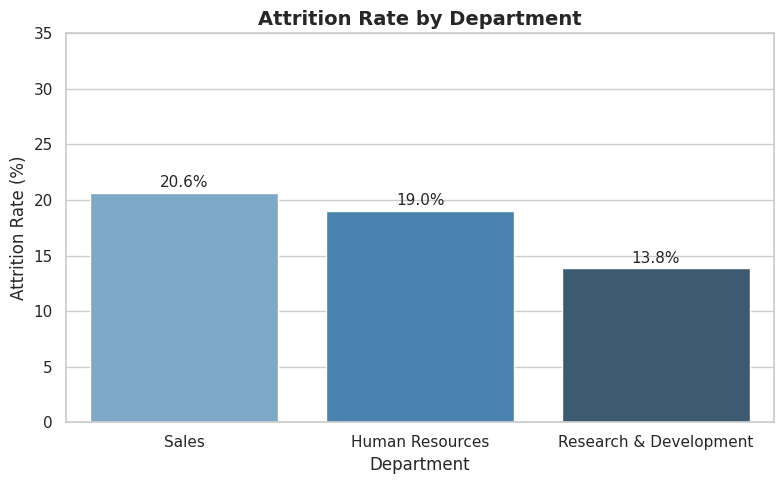

In [7]:
# Attrition rate by Department
dept_attrition = df.groupby('Department')['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reset_index()
dept_attrition.columns = ['Department', 'Attrition Rate (%)']
dept_attrition = dept_attrition.sort_values('Attrition Rate (%)', ascending=False)

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=dept_attrition, x='Department', y='Attrition Rate (%)', palette='Blues_d')
plt.title('Attrition Rate by Department', fontsize=14, fontweight='bold')
plt.ylim(0, 35)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('attrition_by_department.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_3262/3433288500.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=tenure_attrition, x='TenureBand', y='Attrition Rate (%)', palette='Reds_d')


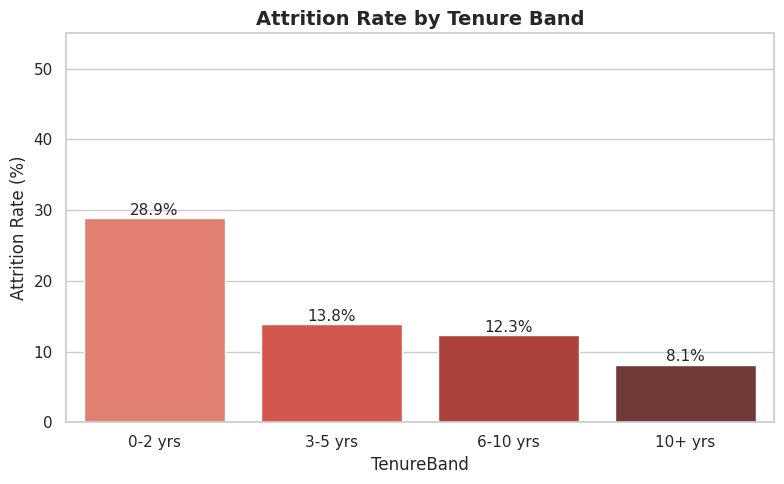

In [8]:
# Attrition rate by Tenure Band
tenure_attrition = df.groupby('TenureBand', observed=True)['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reset_index()
tenure_attrition.columns = ['TenureBand', 'Attrition Rate (%)']

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=tenure_attrition, x='TenureBand', y='Attrition Rate (%)', palette='Reds_d')
plt.title('Attrition Rate by Tenure Band', fontsize=14, fontweight='bold')
plt.ylim(0, 55)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('attrition_by_tenure.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_3262/832882713.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=ot_attrition, x='OverTime', y='Attrition Rate (%)', palette='Set1')


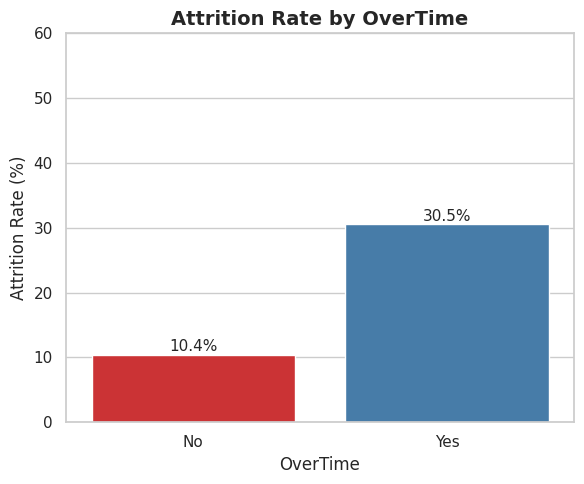

In [9]:
# Attrition by OverTime
ot_attrition = df.groupby('OverTime')['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reset_index()
ot_attrition.columns = ['OverTime', 'Attrition Rate (%)']

plt.figure(figsize=(6, 5))
ax = sns.barplot(data=ot_attrition, x='OverTime', y='Attrition Rate (%)', palette='Set1')
plt.title('Attrition Rate by OverTime', fontsize=14, fontweight='bold')
plt.ylim(0, 60)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('attrition_by_overtime.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_3262/2777263854.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', palette='pastel')


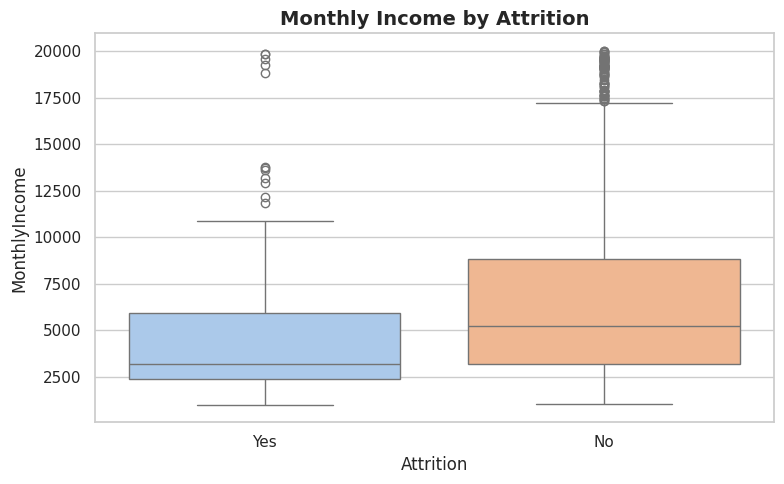

Median income — Stayed: 5204.0
Median income — Left:   3202.0


In [10]:
# Monthly Income distribution by Attrition
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', palette='pastel')
plt.title('Monthly Income by Attrition', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('income_by_attrition.png', dpi=150, bbox_inches='tight')
plt.show()

print('Median income — Stayed:', df[df['Attrition']=='No']['MonthlyIncome'].median())
print('Median income — Left:  ', df[df['Attrition']=='Yes']['MonthlyIncome'].median())

---
## 📌 Step 4 — Key Findings

| # | Finding | Attrition Rate |
|---|---------|----------------|
| 1 | **Employees with 0–2 years tenure leave at ~47%** — the first 2 years are the highest-risk window | ~47% |
| 2 | **Employees doing OverTime leave at ~31%** vs ~10% for those who don't | ~31% vs ~10% |
| 3 | **Sales department has the highest attrition** (~21%) — followed by HR (~19%) | ~21% |

**Business Recommendations:**
- Focus onboarding & engagement programs on employees in their first 2 years
- Review OverTime policies — employees working extra hours are 3x more likely to leave
- Investigate compensation and career growth in the Sales department


In [11]:
# Summary stats
print('=== Key Numbers ===')
print(f'Total Employees       : {len(df)}')
print(f'Employees Left        : {(df["Attrition"]=="Yes").sum()}')
print(f'Overall Attrition Rate: {(df["Attrition"]=="Yes").mean()*100:.1f}%')
print(f'Highest Risk Group    : 0-2 years tenure')
print(f'OverTime Attrition    : ~31% vs ~10% (no overtime)')

=== Key Numbers ===
Total Employees       : 1470
Employees Left        : 237
Overall Attrition Rate: 16.1%
Highest Risk Group    : 0-2 years tenure
OverTime Attrition    : ~31% vs ~10% (no overtime)
